<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h1 style="margin:0; padding:8px 0;">
     Cofee Sale Analysis
  </h1>
</div>

## Objective

The primary objective of this notebook is to perform an exploratory data analysis of coffee shop transaction data to uncover sales patterns, product popularity, and temporal trends. By analyzing transaction records across months, weekdays, and hours, this analysis aims to identify peak business periods, best-selling products, and customer payment preferences. The insights derived will inform inventory planning, optimize vending machine layouts, and determine ideal restocking schedules, ultimately supporting data-driven business decisions to improve operational efficiency and enhance customer satisfaction.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [12]:
coffee_data= pd.read_csv('Cofee_sales.csv')

## EDA

In [13]:
coffee_data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [15]:
coffee_data.shape

(1133, 6)

There are 1133 rows of data with 6 features

In [17]:
coffee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


**Checking if there is any null**

In [18]:
coffee_data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

The null values in card shows they might have paid using cash

In [19]:
coffee_data.duplicated().sum()

np.int64(0)

No duplicate values

In [20]:
coffee_data.describe().T

,count,mean,std,min,25%,50%,75%,max
money,1133.0,33.105808,5.035366,18.12,28.9,32.82,37.72,40.0


In [21]:
coffee_data.loc[:,['cash_type','card','coffee_name']].describe().T


,count,unique,top,freq
cash_type,1133,2,card,1044
card,1044,446,ANON-0000-0000-0012,88
coffee_name,1133,8,Americano with Milk,268


- 2 unique values of 'cash_type'.
- 8 different coffee types with 'Americano with Milk' is the most popular product.
  
Let's check the transactions with missing value in 'card'

In [22]:
coffee_data[coffee_data['card'].isnull()]['cash_type'].value_counts()

cash_type
cash    89
Name: count, dtype: int64

All of the transactions with null 'card' information are from cash users.

<Axes: >

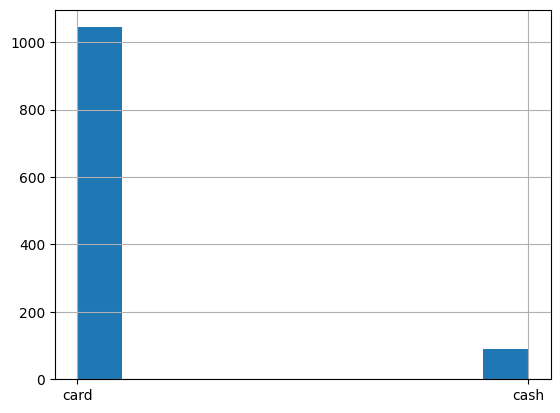

In [23]:
coffee_data['cash_type'].hist()

In [24]:
coffee_data['cash_type'].value_counts(normalize=True)

cash_type
card    0.921447
cash    0.078553
Name: proportion, dtype: float64

~92% of the transactions are from card users.

In [31]:
pd.DataFrame(coffee_data['coffee_name'].value_counts(normalize=
True).sort_values(ascending=False).round(4)*100).T

coffee_name,Americano with Milk,Latte,Cappuccino,Americano,Cortado,Hot Chocolate,Espresso,Cocoa
proportion,23.65,21.45,17.3,14.92,8.74,6.53,4.32,3.09


In [32]:
#Convert date and datetime to datetme format

coffee_data['date']=pd.to_datetime(coffee_data['date'])
coffee_data['datetime']=pd.to_datetime(coffee_data['datetime'])

In [33]:
#Create column of Month, Weekdays, and Hours

coffee_data['month']=coffee_data['date'].dt.strftime('%Y-%m')
coffee_data['day']=coffee_data['date'].dt.strftime('%w')
coffee_data['hour']=coffee_data['datetime'].dt.strftime('%H')


In [34]:
coffee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1133 non-null   datetime64[ns]
 1   datetime     1133 non-null   datetime64[ns]
 2   cash_type    1133 non-null   object        
 3   card         1044 non-null   object        
 4   money        1133 non-null   float64       
 5   coffee_name  1133 non-null   object        
 6   month        1133 non-null   object        
 7   day          1133 non-null   object        
 8   hour         1133 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 79.8+ KB


In [35]:
coffee_data.head()

,date,datetime,cash_type,card,money,coffee_name,month,day,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,5,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,5,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,5,13


**Checking the time stamp :**

In [36]:
[coffee_data['date'].min(),coffee_data['date'].max()]

[Timestamp('2024-03-01 00:00:00'), Timestamp('2024-07-31 00:00:00')]

In [38]:
revenue_data=  coffee_data.groupby(['coffee_name']).sum(['money']).reset_index().sort_values(by='money',ascending=False)

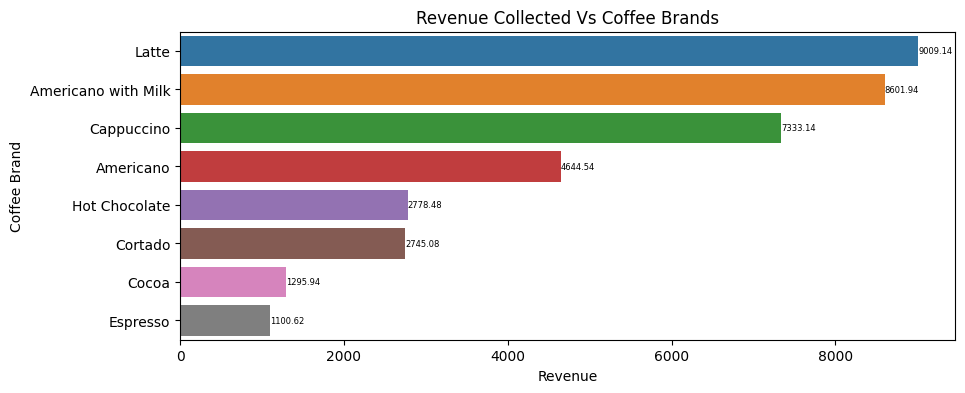

In [44]:

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=revenue_data, 
    x='money', 
    y='coffee_name', 
    hue='coffee_name', 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fontsize=6)

plt.xlabel('Revenue')
plt.ylabel('Coffee Brand') 
plt.title("Revenue Collected Vs Coffee Brands")

plt.show()

**Latte** is the product with the highest revenue, while Expresso is the one at the
bottom. Then let's check the monthly data.

In [47]:
monthly_sales = coffee_data.groupby(['coffee_name','month']).count()['date'].reset_index().rename(columns={'date':'count'}).pivot(index='month',columns='coffee_name',values='count').reset_index()
monthly_sales

coffee_name,month,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03,36,34,20,6,30,10,22,48
1,2024-04,35,42,43,6,19,7,13,31
2,2024-05,48,58,55,9,17,8,14,58
3,2024-06,14,69,46,5,19,10,14,50
4,2024-07,36,65,32,9,14,14,11,56


In [48]:
monthly_sales.describe().T.loc[:,['min','max']]

,min,max
coffee_name,,
Americano,14.0,48.0
Americano with Milk,34.0,69.0
Cappuccino,20.0,55.0
Cocoa,5.0,9.0
Cortado,14.0,30.0
Espresso,7.0,14.0
Hot Chocolate,11.0,22.0
Latte,31.0,58.0


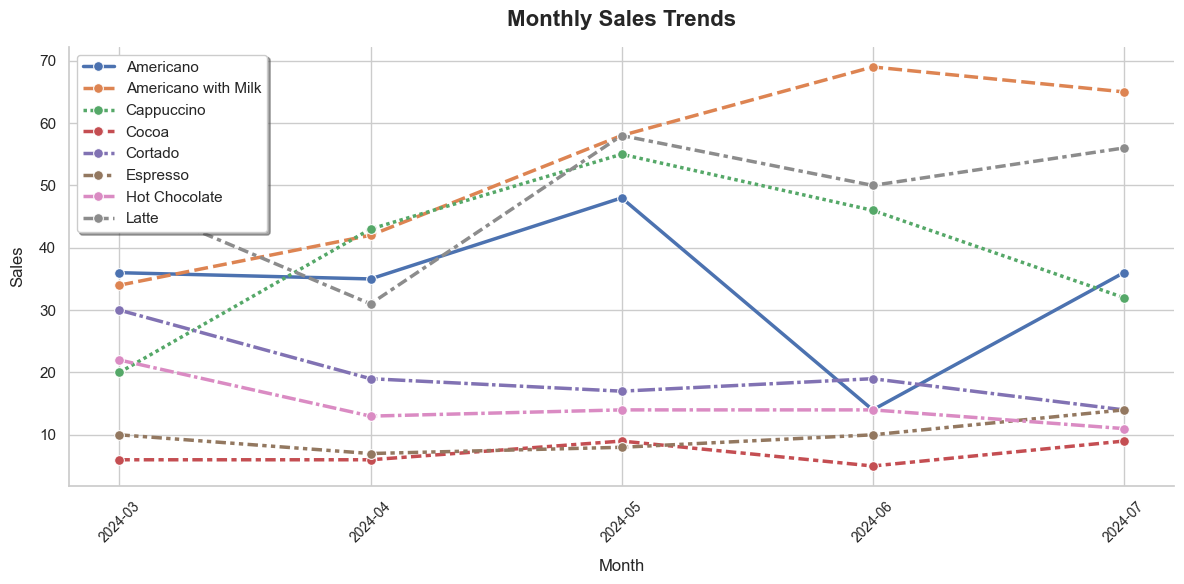

In [52]:
sns.set_theme(style="whitegrid", palette="deep")

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_sales, 
    linewidth=2.5, 
    marker='o', 
    markersize=7
)
plt.title("Monthly Sales Trends", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12, labelpad=10)
plt.ylabel("Sales", fontsize=12, labelpad=10)


plt.xticks(
    ticks=range(len(monthly_sales['month'])), 
    labels=monthly_sales['month'], 
    rotation=45, 
    fontsize=10
)

plt.legend(loc='upper left', frameon=True, shadow=True)


sns.despine()

plt.tight_layout()
plt.show()

In [53]:
weekday_sales = coffee_data.groupby(['day']).count()['date'].reset_index().rename(columns={'date':'count'})
weekday_sales

,day,count
0,0,151
1,1,151
2,2,185
3,3,165
4,4,164
5,5,163
6,6,154


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31140\3491181041.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


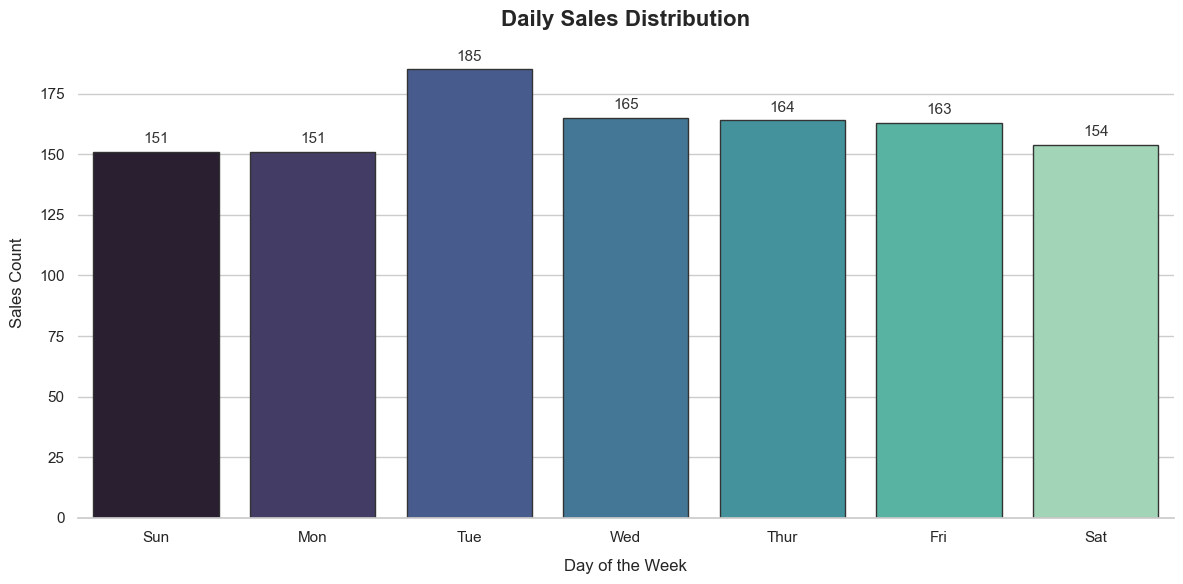

In [55]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=weekday_sales, 
    x='day', 
    y='count', 
    palette="mako", 
    edgecolor=".2"
)


for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=11, color="#333333")

plt.title("Daily Sales Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Day of the Week", fontsize=12, labelpad=10)
plt.ylabel("Sales Count", fontsize=12, labelpad=10)

plt.xticks(
    ticks=range(7), 
    labels=['Sun', 'Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat'], 
    fontsize=11
)

sns.despine(left=True)

plt.tight_layout()
plt.show()

In [56]:
daily_sales = coffee_data.groupby(['coffee_name','date']).count()['datetime'].reset_index().reset_index().rename(columns={'datetime':'count'}).pivot(index='date',columns='coffee_name',values='count').reset_index().fillna(0)
daily_sales

coffee_name,date,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03-01,1.0,4.0,0.0,1.0,0.0,0.0,3.0,2.0
1,2024-03-02,3.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2024-03-03,1.0,2.0,0.0,1.0,2.0,0.0,2.0,2.0
3,2024-03-04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0
4,2024-03-05,0.0,0.0,0.0,1.0,1.0,0.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...
145,2024-07-27,0.0,5.0,4.0,0.0,0.0,2.0,0.0,2.0
146,2024-07-28,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
147,2024-07-29,3.0,2.0,2.0,1.0,0.0,0.0,2.0,1.0
148,2024-07-30,2.0,12.0,2.0,0.0,3.0,2.0,0.0,3.0


In [57]:
daily_sales.iloc[:,1:].describe().T.loc[:,['min','max']]

,min,max
coffee_name,,
Americano,0.0,5.0
Americano with Milk,0.0,12.0
Cappuccino,0.0,9.0
Cocoa,0.0,2.0
Cortado,0.0,4.0
Espresso,0.0,4.0
Hot Chocolate,0.0,4.0
Latte,0.0,7.0


In [58]:
hourly_sales = coffee_data.groupby(['hour']).count()['date'].reset_index().rename(columns={'date':'count'})
hourly_sales

,hour,count
0,07,13
1,08,44
2,09,50
3,10,133
4,11,103
5,12,87
6,13,78
7,14,76
8,15,65
9,16,77


C:\Users\ASUS\AppData\Local\Temp\ipykernel_31140\1034759356.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


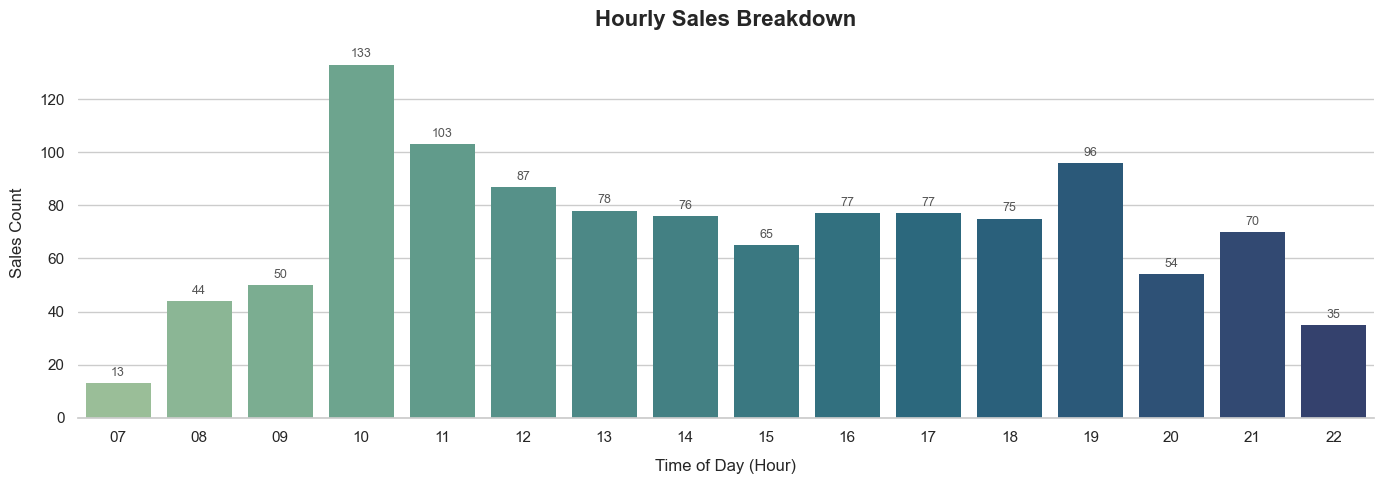

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

ax = sns.barplot(
    data=hourly_sales, 
    x='hour', 
    y='count', 
    palette="crest", 
    edgecolor="none"
)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, color="#555555", padding=3)

plt.title("Hourly Sales Breakdown", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time of Day (Hour)", fontsize=12, labelpad=10)
plt.ylabel("Sales Count", fontsize=12, labelpad=10)

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

In [60]:
hourly_sales_by_coffee = coffee_data.groupby(['hour','coffee_name']).count()['date'].reset_index().rename(columns={'date':'count'}).pivot(index='hour',columns='coffee_name',values='count').fillna(0).reset_index()
hourly_sales_by_coffee

coffee_name,hour,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,07,5.0,4.0,1.0,0.0,1.0,0.0,0.0,2.0
1,08,10.0,7.0,8.0,1.0,6.0,0.0,0.0,12.0
2,09,8.0,16.0,6.0,1.0,5.0,3.0,0.0,11.0
3,10,20.0,31.0,10.0,4.0,8.0,2.0,7.0,51.0
4,11,21.0,25.0,16.0,1.0,13.0,6.0,8.0,13.0
5,12,14.0,26.0,15.0,3.0,7.0,6.0,3.0,13.0
6,13,18.0,18.0,10.0,2.0,12.0,3.0,4.0,11.0
7,14,15.0,18.0,13.0,4.0,6.0,5.0,2.0,13.0
8,15,14.0,15.0,8.0,0.0,3.0,4.0,6.0,15.0
9,16,10.0,18.0,12.0,3.0,12.0,5.0,4.0,13.0


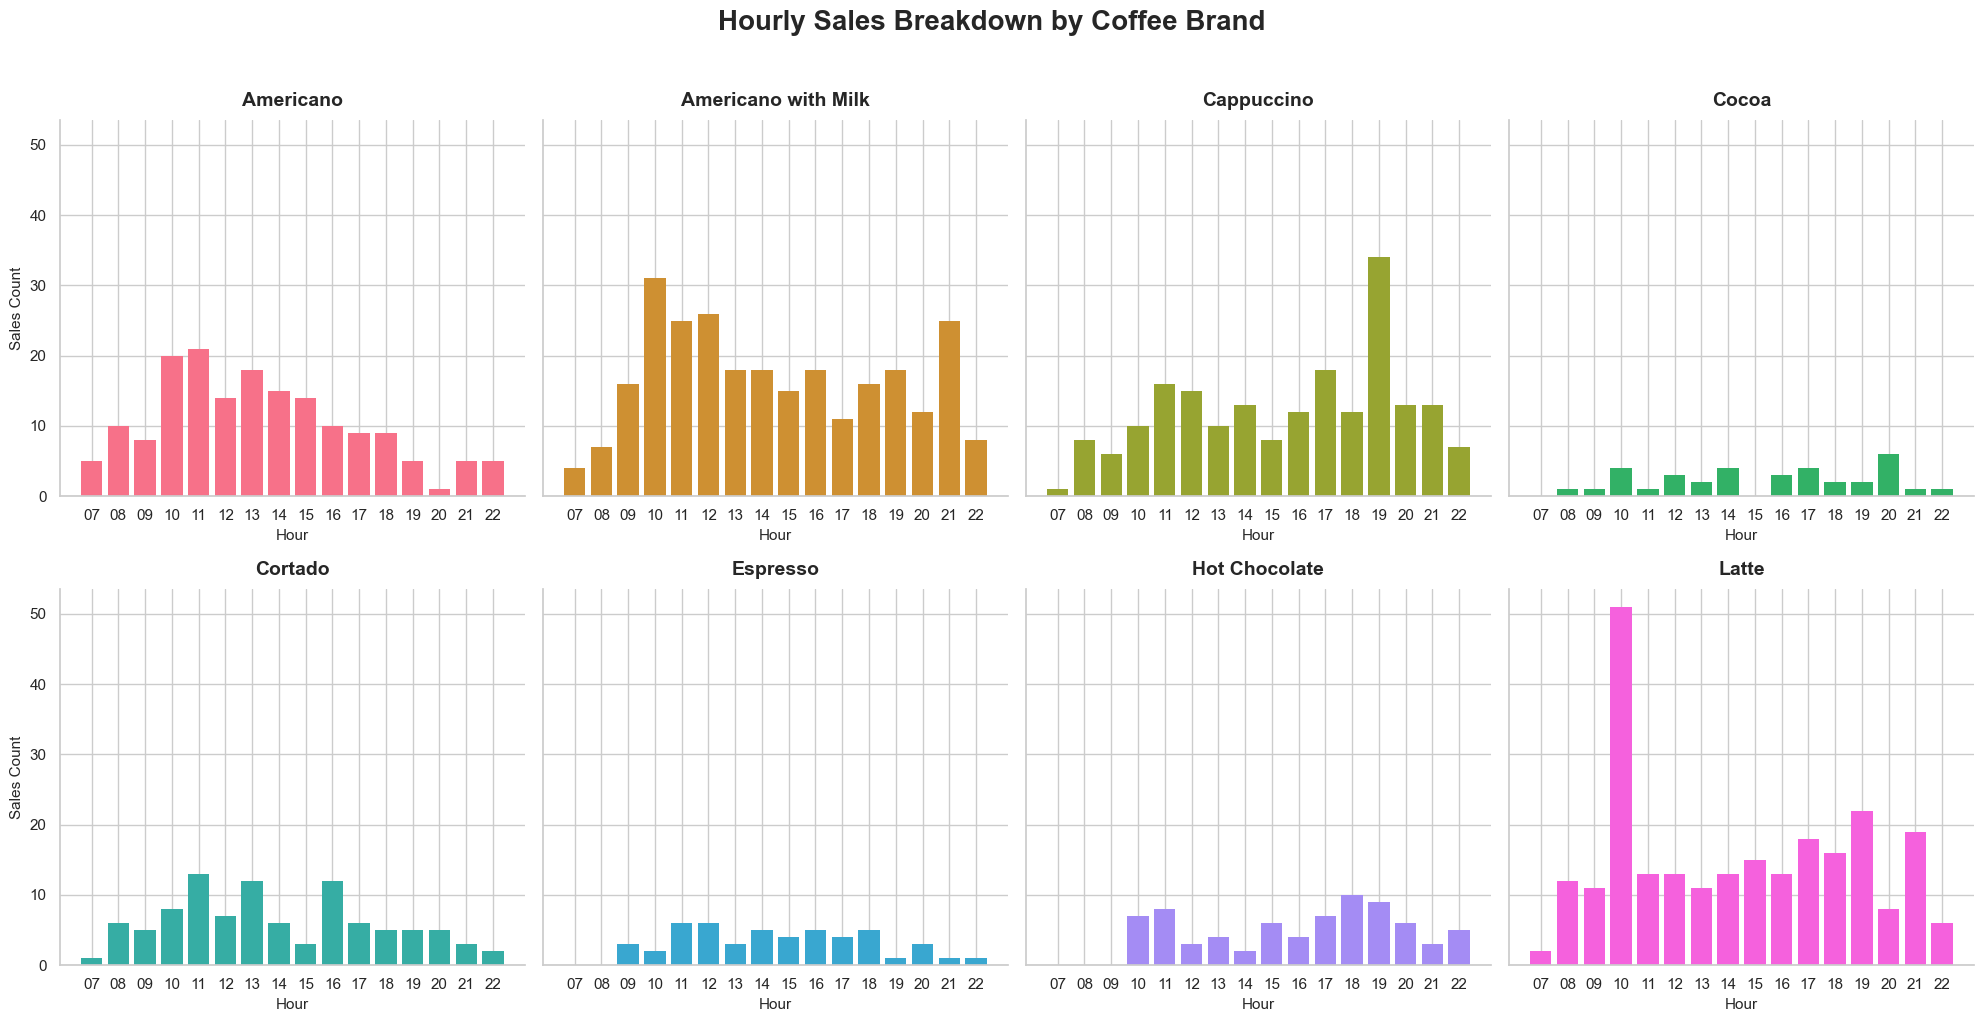

In [61]:
sns.set_theme(style="whitegrid")

fig, axs = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
axs = axs.flatten()

coffee_brands = hourly_sales_by_coffee.columns[1:]

colors = sns.color_palette("husl", len(coffee_brands))

for i, column in enumerate(coffee_brands):
    axs[i].bar(
        hourly_sales_by_coffee['hour'], 
        hourly_sales_by_coffee[column], 
        color=colors[i],
        edgecolor='none'
    )

    axs[i].set_title(column, fontsize=14, fontweight='bold', pad=10)
    axs[i].set_xlabel('Hour', fontsize=11)
    
    if i % 4 == 0:
        axs[i].set_ylabel('Sales Count', fontsize=11)

    axs[i].spines[['top', 'right']].set_visible(False)

for j in range(len(coffee_brands), len(axs)):
    fig.delaxes(axs[j])

fig.suptitle(
    "Hourly Sales Breakdown by Coffee Brand", 
    fontsize=20, 
    fontweight='bold', 
    y=1.02 
)

plt.tight_layout()
plt.show()

The plots above illustrate the shopping traffic for each product throughout the day. Notably, all products experience a peak in traffic around **10:00 AM**, with this trend being particularly pronounced for **Latte**. Additionally, Cappuccino, Cocoa, and Hot Chocolate tend to be more popular during the evening hours, specifically **between 6:00pm and 8:00pm.**

**Now, let us try some model for the prediction:**

**i) Prepare daily total sales**

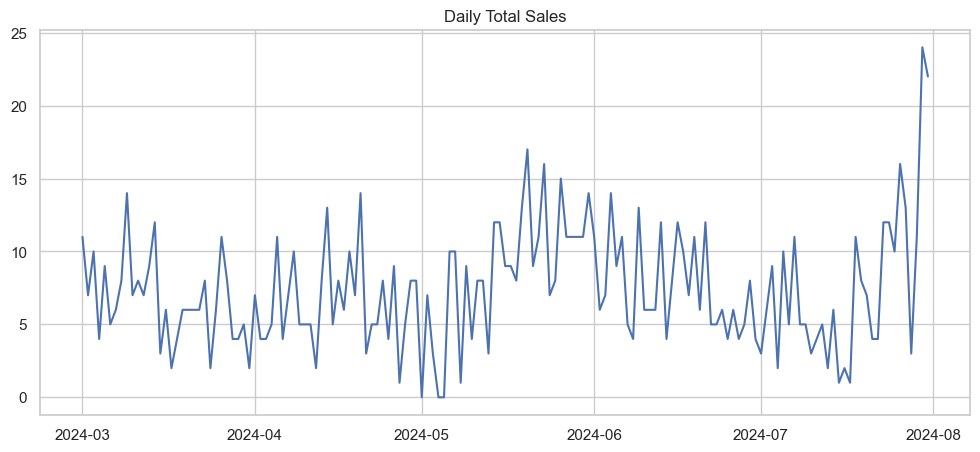

In [63]:
#Aggregate to total daily sales
daily_total = daily_sales.copy()
daily_total['total'] = daily_total.iloc[:, 1:].sum(axis=1)
daily_total = daily_total[['date', 'total']].set_index('date').sort_index()
daily_total.index = pd.to_datetime(daily_total.index)

date_range = pd.date_range(start=daily_total.index.min(), end=daily_total.index.max(), freq='D')
daily_total = daily_total.reindex(date_range, fill_value=0)

plt.figure(figsize=(12,5))
plt.plot(daily_total.index, daily_total['total'])
plt.title('Daily Total Sales')
plt.show()

**ii) Feature engineering**

In [64]:
#Creating time-based features and lags

df = daily_total.copy()
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_month'] = df.index.day
df['week_of_year'] = df.index.isocalendar().week.astype(int)

for lag in [1, 2, 3, 7, 14]:
    df[f'lag_{lag}'] = df['total'].shift(lag)

# Rolling statistics
df['rolling_mean_7'] = df['total'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['total'].shift(1).rolling(7).std()

df = df.dropna()
print(f"Final shape: {df.shape}")

Final shape: (139, 12)


In [65]:
# Split data
split = int(len(df) * 0.8)

train, test = df.iloc[:split], df.iloc[split:]

print(f"Train: {train.index[0]} to {train.index[-1]}")
print(f"Test: {test.index[0]} to {test.index[-1]}")

Train: 2024-03-15 00:00:00 to 2024-07-03 00:00:00
Test: 2024-07-04 00:00:00 to 2024-07-31 00:00:00


In [66]:
#Persistence forecast

persistence_pred = test['total'].shift(1)
persistence_pred.iloc[0] = train['total'].iloc[-1]

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_persistence = mean_absolute_error(test['total'], persistence_pred)
rmse_persistence = np.sqrt(mean_squared_error(test['total'], persistence_pred))
print(f"Persistence MAE: {mae_persistence:.2f}, RMSE: {rmse_persistence:.2f}")

Persistence MAE: 4.25, RMSE: 5.47


**iii) SARIMA Model**

In [69]:
# Cell 5: 
from pmdarima import auto_arima

model_arima = auto_arima(
    train['total'],
    seasonal=True, m=7,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

forecast_arima = model_arima.predict(n_periods=len(test))

mae_arima = mean_absolute_error(test['total'], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test['total'], forecast_arima))
print(f"SARIMA MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=586.690, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=647.466, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=621.878, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=586.455, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=645.482, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=585.538, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=586.797, Time=0.03 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=587.677, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=586.466, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=585.491, Time=0.07 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=586.708, Time=0.16 sec
 ARIMA(0,1,2)(0,0,1)[7] intercept   : AIC=586.344, Time=0.18 sec
 ARIMA(0,1,2)(1,0,1)[7] intercept   : AIC=587.478, Time=0.35 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=585.506, Time=0.10 sec
 ARIMA(0,1,3)(0,0,0)[7] intercept   : AIC=583.5

**XGBoost**

In [70]:
import xgboost as xgb

feature_cols = ['day_of_week', 'month', 'day_of_month', 'week_of_year',
                'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
                'rolling_mean_7', 'rolling_std_7']

X_train = train[feature_cols]
y_train = train['total']
X_test = test[feature_cols]
y_test = test['total']

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print(f"XGBoost MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")

XGBoost MAE: 4.75, RMSE: 6.07


**Comparing the results :**

         Model       MAE      RMSE
0  Persistence  4.250000  5.467436
1       SARIMA  4.533727  6.109710
2      XGBoost  4.750251  6.073019


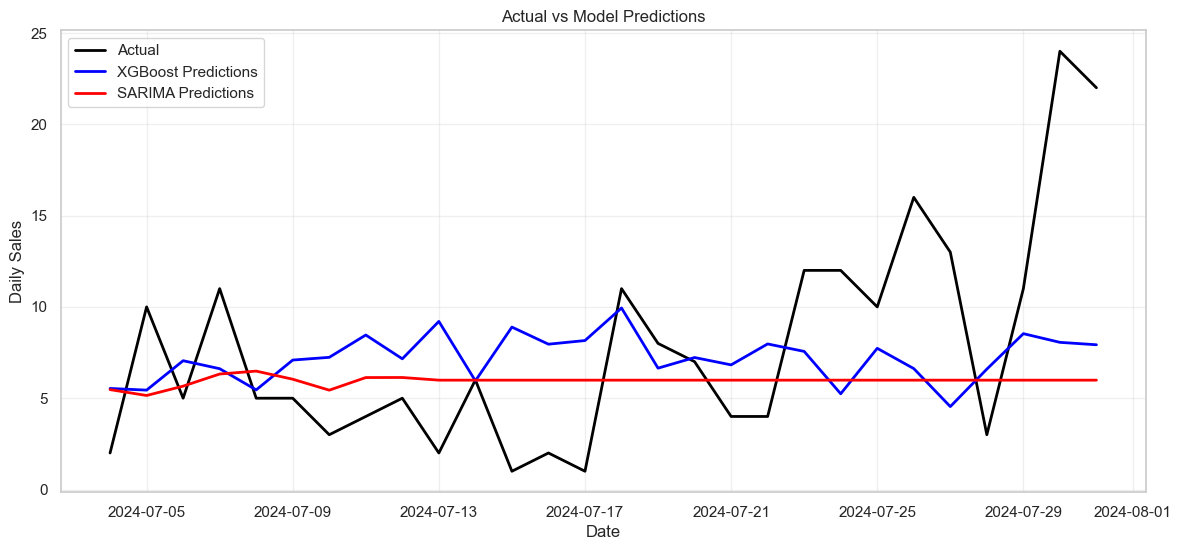

In [74]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Persistence', 'SARIMA', 'XGBoost'],
    'MAE': [mae_persistence, mae_arima, mae_xgb],
    'RMSE': [rmse_persistence, rmse_arima, rmse_xgb]
})
print(results)

# Plot actual vs predictions
plt.figure(figsize=(14,6))
plt.plot(test.index, test['total'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, pred_xgb, label='XGBoost Predictions', linewidth=2, color='blue')
plt.plot(test.index, forecast_arima, label='SARIMA Predictions', linewidth=2, color='red')
plt.legend()
plt.title('Actual vs Model Predictions')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.grid(True, alpha=0.3)
plt.show()

# Ensemble predictions

                 Model       MAE      RMSE
0          Persistence  4.250000  5.467436
1               SARIMA  4.533727  6.109710
2              XGBoost  4.750251  6.073019
3       Ensemble (Avg)  4.633847  6.027272
4  Ensemble (Weighted)  4.631512  6.027740


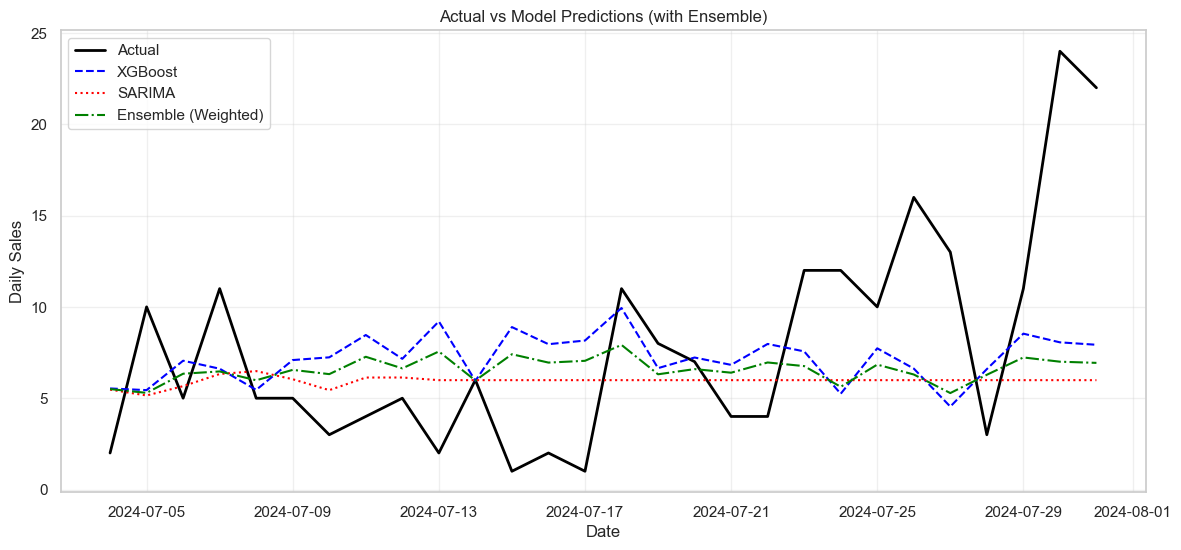

In [78]:
ensemble_avg = (forecast_arima + pred_xgb) / 2

weights = {
    'sarima': 1 / mae_arima,
    'xgb': 1 / mae_xgb
}
total_weight = weights['sarima'] + weights['xgb']
ensemble_weighted = (weights['sarima'] * forecast_arima + weights['xgb'] * pred_xgb) / total_weight

mae_avg = mean_absolute_error(test['total'], ensemble_avg)
rmse_avg = np.sqrt(mean_squared_error(test['total'], ensemble_avg))
mae_weighted = mean_absolute_error(test['total'], ensemble_weighted)
rmse_weighted = np.sqrt(mean_squared_error(test['total'], ensemble_weighted))

results_ensemble = pd.DataFrame({
    'Model': ['Persistence', 'SARIMA', 'XGBoost', 'Ensemble (Avg)', 'Ensemble (Weighted)'],
    'MAE': [mae_persistence, mae_arima, mae_xgb, mae_avg, mae_weighted],
    'RMSE': [rmse_persistence, rmse_arima, rmse_xgb, rmse_avg, rmse_weighted]
})
print(results_ensemble)

plt.figure(figsize=(14,6))
plt.plot(test.index, test['total'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, pred_xgb, label='XGBoost', linestyle='--', color='blue')
plt.plot(test.index, forecast_arima, label='SARIMA', linestyle=':', color='red')
plt.plot(test.index, ensemble_weighted, label='Ensemble (Weighted)', linestyle='-.', color='green')
plt.legend()
plt.title('Actual vs Model Predictions (with Ensemble)')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.grid(True, alpha=0.3)
plt.show()

                 Model    MAE   RMSE     R²  MAPE (%)  Accuracy (±20%)
0          Persistence  4.250  5.467  0.121    89.898           25.000
1               SARIMA  4.534  6.110 -0.098    93.453           10.714
2              XGBoost  4.750  6.073 -0.085   125.937           17.857
3       Ensemble (Avg)  4.634  6.027 -0.068   109.579           10.714
4  Ensemble (Weighted)  4.632  6.028 -0.069   109.203           10.714


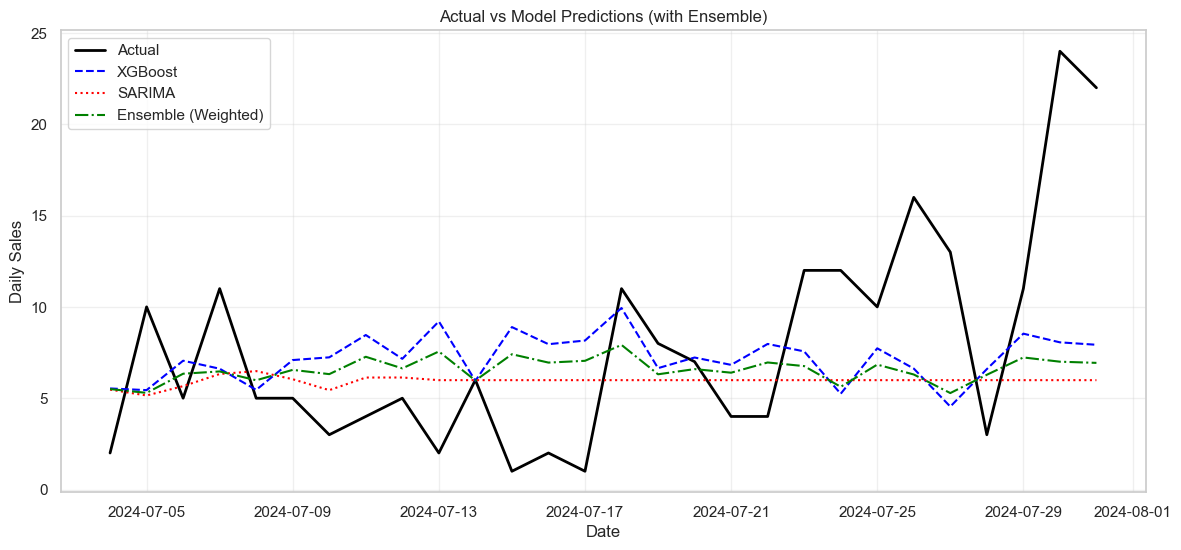

In [76]:
from sklearn.metrics import r2_score

ensemble_avg = (forecast_arima + pred_xgb) / 2

# Weighted ensemble
weights = {
    'sarima': 1 / mae_arima,
    'xgb': 1 / mae_xgb
}
total_weight = weights['sarima'] + weights['xgb']
ensemble_weighted = (weights['sarima'] * forecast_arima + weights['xgb'] * pred_xgb) / total_weight

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def accuracy_within_tolerance(y_true, y_pred, tolerance=0.20):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    within = np.abs((y_true - y_pred) / y_true) <= tolerance
    return np.mean(within) * 100

models = {
    'Persistence': persistence_pred,
    'SARIMA': forecast_arima,
    'XGBoost': pred_xgb,
    'Ensemble (Avg)': ensemble_avg,
    'Ensemble (Weighted)': ensemble_weighted
}

results_list = []
for name, pred in models.items():
    mae = mean_absolute_error(test['total'], pred)
    rmse = np.sqrt(mean_squared_error(test['total'], pred))
    r2 = r2_score(test['total'], pred)
    mape = mean_absolute_percentage_error(test['total'], pred)
    acc_20 = accuracy_within_tolerance(test['total'], pred, tolerance=0.20)
    
    results_list.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Accuracy (±20%)': acc_20
    })

results_ensemble = pd.DataFrame(results_list)
print(results_ensemble.round(3))

plt.figure(figsize=(14,6))
plt.plot(test.index, test['total'], label='Actual', color='black', linewidth=2)
plt.plot(test.index, pred_xgb, label='XGBoost', linestyle='--', color='blue')
plt.plot(test.index, forecast_arima, label='SARIMA', linestyle=':', color='red')
plt.plot(test.index, ensemble_weighted, label='Ensemble (Weighted)', linestyle='-.', color='green')
plt.legend()
plt.title('Actual vs Model Predictions (with Ensemble)')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.grid(True, alpha=0.3)
plt.show()

**Visual Observations:**

- **XGBoost (Blue line)** – Follows the general trend and fluctuations of actual sales reasonably well. It captures most peaks and troughs, though sometimes overshoots or undershoots extreme values.

- **SARIMA (Red line)** – Produces a smoother forecast that captures the overall pattern but misses some of the sharper spikes in actual sales. This is typical for SARIMA, as it relies on historical patterns and seasonality rather than complex feature interactions.

- **Actual sales (Black line)** – Shows considerable day‑to‑day variability, with several high peaks (some exceeding 60 sales) and low troughs 

### Conclusion
The exploratory analysis of coffee shop transactions revealed key sales patterns: Latte generates the highest revenue, while Americano with Milk is the most frequently purchased item. Peak shopping hours occur around **10 AM**, particularly for Latte, with Cappuccino, Cocoa, and Hot Chocolate showing secondary evening peaks **(6 PM–8 PM)**. Tuesday emerged as the busiest weekday. Predictive modeling, however, proved challenging due to high daily volatility – a simple persistence forecast (using the previous day's sales) consistently outperformed **SARIMA and XGBoost**, with ensembles offering no improvement. The negative R² values and elevated MAPE across all models underscore the difficulty of capturing extreme fluctuations. While descriptive insights can directly inform inventory planning, product placement, and restocking schedules, reliable daily sales forecasting may require additional external features (e.g., weather, holidays) or a shift to weekly aggregation to reduce noise.